--- Searching for robot paths ---
Detected project root directory: /home/cpene/Documents/robot_playground
Asset paths verified.
Detected urdf file: /home/cpene/Documents/robot_playground/robot_models/h1_2/h1_2_handless.urdf
Detected mesh directory: /home/cpene/Documents/robot_playground/robot_models/h1_2
Launching MeshCat...
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7035/static/
Adding a grid to represent the ground.
Loading robot model into Pinocchio...


Gtk-Message: 13:23:45.198: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.


Pinocchio model loaded successfully.
Frame 'left_ground' added successfully.
Frame 'right_ground' added successfully.

Environment is ready !
--- Pinocchio model datas ---
Robot name: h1_2
Configuration dimension (nq): 34
Velocity dimension (nv): 33
q0 = [0.   0.   1.03 0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]
dim q0 = (34,)


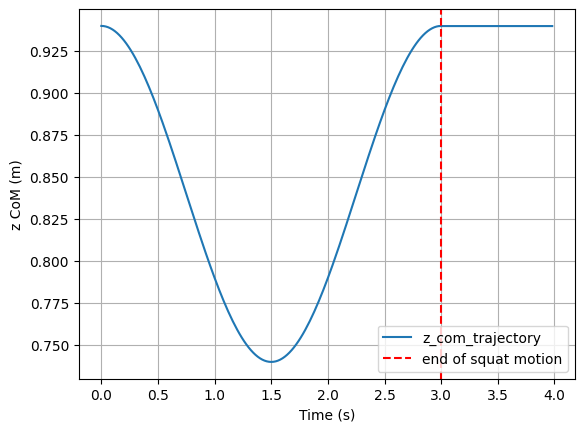

In [14]:
# import robot_loader from scripts
import pinocchio as pin
import crocoddyl
import os
import numpy as np
from scripts.robot_loader import *
import meshcat.geometry as mg
import matplotlib.pyplot as plt

# load model on Meshcat
model, collision_model, visual_model, robot_visualizer, viz = launch_visualization()

print(f"--- Pinocchio model datas ---")
print(f"Robot name: {model.name}")
print(f"Configuration dimension (nq): {model.nq}")
print(f"Velocity dimension (nv): {model.nv}")

data = model.createData()
robot_visualizer.data = data

# Display some frames
frames_to_display = ["pelvis", "left_ground", "right_ground"]
frame_ids = [model.getFrameId(frame_name) for frame_name in frames_to_display]
robot_visualizer.displayFrames(True, frame_ids)

q0 = pin.neutral(model)
q0[2] = 1.03

print("q0 =", q0)
print("dim q0 =", q0.shape)
robot_visualizer.display(q0)
pin.forwardKinematics(model, data, q0)
pin.updateFramePlacements(model, data)

# get ids for contacts
left_foot_id = model.getFrameId("left_ground")
right_foot_id = model.getFrameId("right_ground")
contact_frame_ids = [left_foot_id, right_foot_id]

# Initial guess
# I want to provide a "valide" command for the first input
v0 = np.zeros(model.nv)
a0 = np.zeros(model.nv)
full_gravity_torques = pin.rnea(model, data, q0, v0, a0)
u0 = full_gravity_torques[6:] # this represent the command to counter gravity.

x0 = np.concatenate([q0, v0]) # This represent initial configuration with v = 0

# create trajectory to be used as reference for the CoM
from scripts.build_squat_ocp import *

TRAJECTORY_DURATION = 3.0
HORIZON_LENGTH = 50
OCP_DT = 0.02

reference_com_trajectory = build_squat_com_trajectory(
    model,
    data,
    q0,
    v0,
    traj_duration=TRAJECTORY_DURATION,
    ocp_dt=OCP_DT,
    horizon_length=HORIZON_LENGTH,
    squat_depth=0.20,
)

t_all = np.arange(len(reference_com_trajectory)) * OCP_DT
z_all = reference_com_trajectory[:, 2]

plt.figure()
plt.plot(t_all, z_all, label="z_com_trajectory")
plt.axvline(TRAJECTORY_DURATION, color='r', linestyle='--', label="end of squat motion")
plt.xlabel("Time (s)")
plt.ylabel("z CoM (m)")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
# define parameters 
HORIZON_LENGTH = 50
OCP_DT = 0.02         # 50 Hz

PHYSICS_DT = 0.001    # 1000 Hz
RATIO_PHYSICS_PER_OCP = int(OCP_DT / PHYSICS_DT)
assert OCP_DT % PHYSICS_DT == 0, "OCP_DT has to be a multiple of PHYSICS_DT"
N_OCP_STEPS = int(TRAJECTORY_DURATION / OCP_DT)

# build OCP
from scripts.build_squat_ocp import *
from mpc_controller.mpc_builder import MPCController

#trajectory = build_com_trajectory()
ocp = build_squat_ocp(x0, model, data, reference_com_trajectory, contact_frame_ids, OCP_DT, HORIZON_LENGTH)

# prepare MPC
mpc = MPCController(
    ocp=ocp,
    x0=x0,
    u0=u0,
    max_iter=10,
    com_ref_traj=reference_com_trajectory,
    verbose=True,
)

nu_ocp = mpc.ocp.problem.runningModels[0].nu
print("nu_ocp = ", nu_ocp)

# create phycics simulator with different dt.
simulator_diff_model = ocp.problem.runningModels[0].differential
simulator_action_model = crocoddyl.IntegratedActionModelRK(simulator_diff_model, crocoddyl.RKType(4), PHYSICS_DT)
simulator_data = simulator_action_model.createData()

nu_ocp =  27


In [16]:
x_current = x0.copy()

ocp_save = []
physics_log = [x_current.copy()]

for i in range(N_OCP_STEPS):

    dt_ocp, u_optimal = mpc.step(x_current)

    solver = mpc.ocp.solver
    problem = mpc.ocp.problem

    running_costs = []
    for k in range(HORIZON_LENGTH):
        model_k = problem.runningModels[k]
        data_k = problem.runningDatas[k]
        x_k = solver.xs[k]
        u_k = solver.us[k]
        model_k.calc(data_k, x_k, u_k)
        running_costs.append(data_k.cost)

    terminal_model = problem.terminalModel
    terminal_data = problem.terminalData
    x_T = solver.xs[-1]
    terminal_model.calc(terminal_data, x_T)
    terminal_cost = terminal_data.cost

    J_running = float(np.sum(running_costs))
    J_total_check = J_running + terminal_cost

    current_com_ref = []
    T = len(reference_com_trajectory)
    for j in range(HORIZON_LENGTH):
        idx = i + j
        if idx >= T:
            idx = T - 1
        current_com_ref.append(reference_com_trajectory[idx].copy())

    ocp_snapshot = {
        "iteration": i,
        "converged": solver.stop,
        "solver_iterations": solver.iter,
        "cost_total_solver": solver.cost,
        "cost_running_sum": J_running,
        "cost_terminal": terminal_cost,
        "running_costs_per_stage": running_costs,
        "initial_state": x_current.copy(),
        "xs": [x.copy() for x in solver.xs],
        "us": [u.copy() for u in solver.us],
        "com_reference": current_com_ref,
    }
    ocp_save.append(ocp_snapshot)

    for _ in range(RATIO_PHYSICS_PER_OCP):
        simulator_action_model.calc(simulator_data, x_current, u_optimal)
        x_current = simulator_data.xnext.copy()
        physics_log.append(x_current.copy())


SUCCESS: FDDP 92 converged in 9 iterations.
SUCCESS: FDDP 95 converged in 9 iterations.
SUCCESS: FDDP 96 converged in 9 iterations.
SUCCESS: FDDP 97 converged in 4 iterations.
SUCCESS: FDDP 98 converged in 4 iterations.
SUCCESS: FDDP 99 converged in 3 iterations.
SUCCESS: FDDP 101 converged in 7 iterations.
SUCCESS: FDDP 103 converged in 7 iterations.
SUCCESS: FDDP 105 converged in 2 iterations.
SUCCESS: FDDP 106 converged in 2 iterations.
SUCCESS: FDDP 107 converged in 2 iterations.
SUCCESS: FDDP 108 converged in 2 iterations.
SUCCESS: FDDP 109 converged in 2 iterations.
SUCCESS: FDDP 110 converged in 2 iterations.
SUCCESS: FDDP 111 converged in 4 iterations.
SUCCESS: FDDP 112 converged in 4 iterations.
SUCCESS: FDDP 113 converged in 4 iterations.
SUCCESS: FDDP 114 converged in 4 iterations.
SUCCESS: FDDP 115 converged in 4 iterations.
SUCCESS: FDDP 116 converged in 4 iterations.
SUCCESS: FDDP 117 converged in 5 iterations.
SUCCESS: FDDP 118 converged in 5 iterations.
SUCCESS: FDDP 11

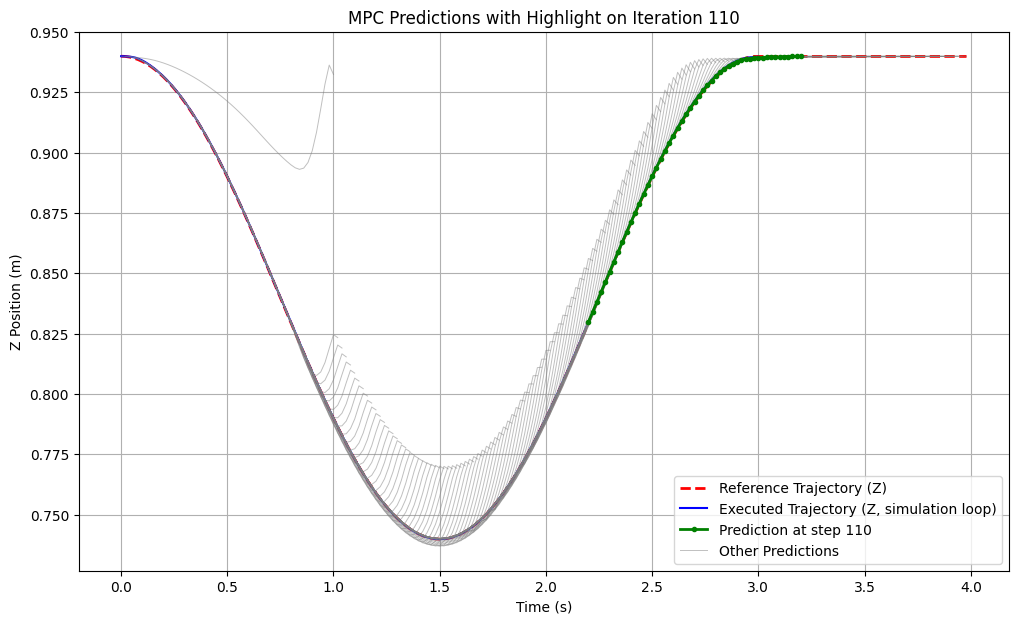

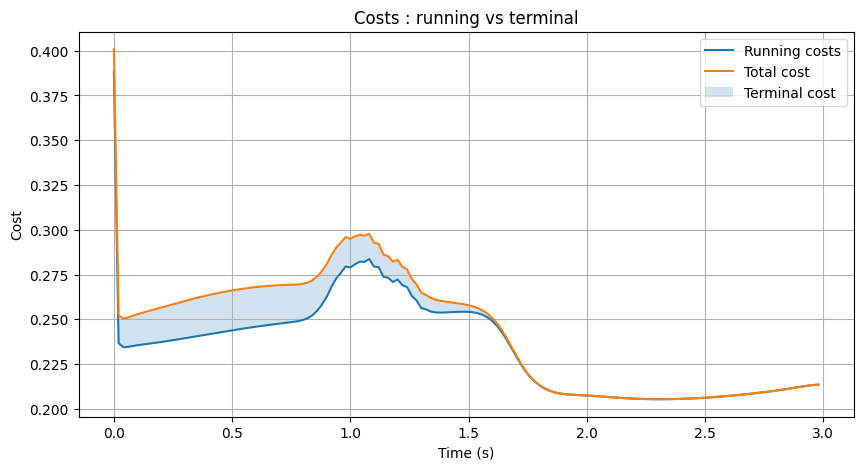

In [17]:
# ==============================================================================
#  Choose an iteration to highlight
# ==============================================================================
ITERATION_TO_HIGHLIGHT = 110
# ==============================================================================

if 'ocp_save' not in locals() or not ocp_save:
    print("'ocp_save' is empty.")

elif ITERATION_TO_HIGHLIGHT >= len(ocp_save):
    print(f"Error : iteration {ITERATION_TO_HIGHLIGHT} is out of range.")

else:
    data_temp = model.createData()

    # Reference trajectory
    z_reference = [com[2] for com in reference_com_trajectory]
    time_axis_reference = np.arange(len(z_reference)) * OCP_DT

    # high frequency trajectory computed by simulator loop
    z_executed_hf = None
    time_axis_executed_hf = None


    data_temp_physics = model.createData()
    z_executed_hf = []

    for x_state in physics_log:
        q = x_state[:model.nq]
        pin.centerOfMass(model, data_temp_physics, q)
        z_executed_hf.append(data_temp_physics.com[0][2])

    z_executed_hf = np.array(z_executed_hf)
    time_axis_executed_hf = np.arange(len(z_executed_hf)) * PHYSICS_DT

    T_max_ref = time_axis_reference[-1]
    valid_idx = time_axis_executed_hf <= T_max_ref
    time_axis_executed_hf = time_axis_executed_hf[valid_idx]
    z_executed_hf = z_executed_hf[valid_idx]


    plt.figure(figsize=(12, 7))
    
    plt.plot(time_axis_reference, z_reference, 'r--', linewidth=2,
             label="Reference Trajectory (Z)")

    if z_executed_hf is not None:
        plt.plot(time_axis_executed_hf, z_executed_hf,
                 'b-', linewidth=1.5,
                 label="Executed Trajectory (Z, simulation loop)")

    for i, snapshot in enumerate(ocp_save):
        time_axis_prediction = (i + np.arange(len(snapshot['xs']))) * OCP_DT

        z_prediction = []
        for x_pred in snapshot['xs']:
            q_pred = x_pred[:model.nq]
            pin.centerOfMass(model, data_temp, q_pred)
            z_prediction.append(data_temp.com[0][2])

        if i == ITERATION_TO_HIGHLIGHT:
            plt.plot(time_axis_prediction, z_prediction,
                     color='green', linestyle='-', linewidth=2,
                     marker='o', markersize=3,
                     label=f"Prediction at step {i}", zorder=10)
        else:
            label = "Other Predictions" if i == 0 else ""
            plt.plot(time_axis_prediction, z_prediction,
                     color='gray', linestyle='-', linewidth=0.7, alpha=0.5,
                     label=label)

    plt.title(f"MPC Predictions with Highlight on Iteration {ITERATION_TO_HIGHLIGHT}")
    plt.xlabel("Time (s)")
    plt.ylabel("Z Position (m)")
    plt.grid(True)

    handles, labels = plt.gca().get_legend_handles_labels()
    order = []
    legend_order = [
        "Reference Trajectory (Z)",
        "Executed Trajectory (Z, simulation loop)",
        f"Prediction at step {ITERATION_TO_HIGHLIGHT}",
        "Other Predictions",
    ]
    for lbl in legend_order:
        if lbl in labels:
            order.append(labels.index(lbl))

    if order:
        plt.legend([handles[idx] for idx in order],
                   [labels[idx] for idx in order])

    plt.show()

# Extract costs 
time_axis = np.arange(len(ocp_save)) * OCP_DT

total_costs   = [snap["cost_total_solver"] for snap in ocp_save]
running_costs = [snap["cost_running_sum"]   for snap in ocp_save]
terminal_costs = [snap["cost_terminal"]    for snap in ocp_save]


plt.figure(figsize=(10, 5))
plt.plot(time_axis, running_costs, label="Running costs")
plt.plot(time_axis, total_costs, label="Total cost")
plt.fill_between(time_axis, running_costs, total_costs, alpha=0.2, label="Terminal cost")
plt.xlabel("Time (s)")
plt.ylabel("Cost")
plt.title("Costs : running vs terminal")
plt.grid(True)
plt.legend()
plt.show()

In [18]:
# Launch the simulation
import time

OCP_DT = 0.033

q_executed_trajectory = [q0.copy()]
for snapshot in ocp_save:
    x_executed = snapshot['xs'][1]
    q_executed = x_executed[:model.nq]
    q_executed_trajectory.append(q_executed)
    
print("Starting animation...")

for q in q_executed_trajectory:
        robot_visualizer.display(q)
        time.sleep(OCP_DT)

print("\nAnimation finished.")

Starting animation...

Animation finished.
